# Chapter 80 - Token-Level GPT: Building a Token-Level Dataset

A character-level GPT predicts one character ID at a time.

A token-level GPT uses the same next-token objective, but each ID can represent a learned subword such as `"the"`, `" cat"`, or `"ing"`.

This chapter prepares the subword ID sequences that the next training chapter will consume.

## Learning goals

By the end of this chapter, you will be able to:

- split embedded source documents into training and validation text;
- train a homemade tokenizer on training text only;
- encode both splits into subword token IDs;
- inspect the first 100 training IDs and decoded subwords;
- report vocabulary and sequence statistics;
- plot training-token frequencies;
- create deterministic shifted GPT batches; and
- explain the sequence-length and vocabulary-size tradeoff.

## The data unit changes, not the objective

Character-level training might shift these tokens:

```text
input:  ["t", "h", "e", " ", "c", "a"]
target: ["h", "e", " ", "c", "a", "t"]
```

Token-level training performs the same shift on larger units:

```text
input:  ["the", " cat", " sat"]
target: [" cat", " sat", " on"]
```

GPT receives integer IDs in either case.

Only the tokenizer-defined meaning of each ID changes.

## Terms

A **token-level dataset** is a sequence of subword token IDs used as model input and targets.

A **training split** supplies examples used for optimizer updates.

A **validation split** is held out from optimizer updates and estimates performance on unseen text.

A **token frequency** is the number of occurrences of one token ID in a chosen split.

A **vocabulary size** is the number of distinct IDs the tokenizer can assign, including cumulative learned tokens that may not occur in every encoded split.

## Split source documents before tokenizer training

The embedded passage is from Lewis Carroll's *Alice's Adventures in Wonderland*, a public-domain source in the United States.

The first three paragraphs are training documents, and the final paragraph is validation text.

Training the tokenizer only on the training documents avoids using held-out pair frequencies to choose merges.

This is more honest than repeating one passage many times and placing an identical copy in validation.

In [1]:
training_documents = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a daisy
chain would be worth the trouble of getting up and picking the daisies, when
suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
be too late! But when the rabbit actually took a watch out of its waistcoat
pocket, and looked at it, and then hurried on, Alice started to her feet.""",
]

validation_document = """The rabbit hole went straight on like a tunnel for some way,
and then dipped suddenly down, so suddenly that Alice had not a moment to think
about stopping herself before she found herself falling down what seemed to be
a very deep well."""

training_text = "\n\n".join(training_documents)
validation_text = validation_document

validation_only_characters = sorted(set(validation_text) - set(training_text))

print("Training documents:", len(training_documents))
print("Training characters:", len(training_text))
print("Validation characters:", len(validation_text))
print("Validation-only characters:", validation_only_characters)
print()
print("Training preview:")
print(training_text[:300])

assert not validation_only_characters

Training documents: 3
Training characters: 896
Validation characters: 237
Validation-only characters: []

Training preview:
Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?




This embedded fixture deliberately gives validation no unseen starting characters, so the homemade character-initialized tokenizer can encode it.

A real system needs a byte fallback, unknown-token policy, or broader fixed tokenizer when held-out data contains unseen characters.

## Tokenizer implementation

The implementation retains the earlier chapter invariants:

- pair-frequency ties use lexical order;
- a merge pass replaces non-overlapping occurrences;
- encoding replays merges in learned order; and
- the vocabulary retains every base character and every learned token.

No start, end, unknown, or padding tokens are needed for these known continuous streams.

In [2]:
from collections import Counter
from dataclasses import dataclass

TokenPair = tuple[str, str]


@dataclass(frozen=True)
class MergeRule:
    index: int
    pair: TokenPair
    new_token: str
    pair_count: int
    replacement_count: int


def count_adjacent_token_pairs(
    token_sequence: list[str],
) -> Counter[TokenPair]:
    return Counter(zip(token_sequence, token_sequence[1:], strict=False))


def select_most_frequent_pair(
    pair_counts: Counter[TokenPair],
) -> tuple[TokenPair, int]:
    if not pair_counts:
        raise ValueError("No adjacent token pairs are available.")

    highest_count = max(pair_counts.values())
    tied_pairs = [
        pair
        for pair, count in pair_counts.items()
        if count == highest_count
    ]
    return min(tied_pairs), highest_count


def merge_pair_in_sequence(
    token_sequence: list[str],
    pair_to_merge: TokenPair,
    merged_token: str,
) -> tuple[list[str], int]:
    merged_sequence: list[str] = []
    replacement_count = 0
    position = 0

    while position < len(token_sequence):
        pair_matches = (
            position + 1 < len(token_sequence)
            and token_sequence[position] == pair_to_merge[0]
            and token_sequence[position + 1] == pair_to_merge[1]
        )

        if pair_matches:
            merged_sequence.append(merged_token)
            replacement_count += 1
            position += 2
        else:
            merged_sequence.append(token_sequence[position])
            position += 1

    return merged_sequence, replacement_count


class HomemadeSubwordTokenizer:
    number_of_merges: int
    merge_rules: list[MergeRule]
    base_alphabet: set[str]
    subword_to_id: dict[str, int]
    id_to_subword: dict[int, str]
    is_trained: bool

    def __init__(self, number_of_merges: int) -> None:
        if number_of_merges < 0:
            raise ValueError("number_of_merges must be nonnegative.")

        self.number_of_merges = number_of_merges
        self.merge_rules = []
        self.base_alphabet = set()
        self.subword_to_id = {}
        self.id_to_subword = {}
        self.is_trained = False

    @property
    def vocabulary_size(self) -> int:
        self._check_trained()
        return len(self.subword_to_id)

    def _check_trained(self) -> None:
        if not self.is_trained:
            raise RuntimeError("Tokenizer must be trained before use.")

    def train(self, text: str) -> None:
        if not text:
            raise ValueError("Training text must not be empty.")

        token_sequence = list(text)
        base_alphabet = set(token_sequence)
        vocabulary = set(base_alphabet)
        merge_rules: list[MergeRule] = []

        for merge_index in range(self.number_of_merges):
            pair_counts = count_adjacent_token_pairs(token_sequence)
            if not pair_counts:
                break

            pair_to_merge, pair_count = select_most_frequent_pair(pair_counts)
            new_token = "".join(pair_to_merge)
            if new_token in vocabulary:
                raise RuntimeError(f"Merge token collision for {new_token!r}.")

            token_sequence, replacement_count = merge_pair_in_sequence(
                token_sequence=token_sequence,
                pair_to_merge=pair_to_merge,
                merged_token=new_token,
            )
            merge_rules.append(
                MergeRule(
                    index=merge_index,
                    pair=pair_to_merge,
                    new_token=new_token,
                    pair_count=pair_count,
                    replacement_count=replacement_count,
                )
            )
            vocabulary.add(new_token)

        sorted_vocabulary = sorted(vocabulary)
        self.merge_rules = merge_rules
        self.base_alphabet = base_alphabet
        self.subword_to_id = {
            subword: token_id
            for token_id, subword in enumerate(sorted_vocabulary)
        }
        self.id_to_subword = {
            token_id: subword
            for subword, token_id in self.subword_to_id.items()
        }
        self.is_trained = True

    def encode_to_subwords(self, text: str) -> list[str]:
        self._check_trained()
        unknown_characters = sorted(set(text) - self.base_alphabet)
        if unknown_characters:
            raise ValueError(f"Unknown characters: {unknown_characters!r}.")

        token_sequence = list(text)
        for merge_rule in self.merge_rules:
            token_sequence, _ = merge_pair_in_sequence(
                token_sequence=token_sequence,
                pair_to_merge=merge_rule.pair,
                merged_token=merge_rule.new_token,
            )
        return token_sequence

    def encode(self, text: str) -> list[int]:
        return [
            self.subword_to_id[subword]
            for subword in self.encode_to_subwords(text)
        ]

    def decode_to_subwords(self, token_ids: list[int]) -> list[str]:
        self._check_trained()
        invalid_ids = sorted(set(token_ids) - set(self.id_to_subword))
        if invalid_ids:
            raise ValueError(f"Unknown token IDs: {invalid_ids!r}.")
        return [self.id_to_subword[token_id] for token_id in token_ids]

    def decode(self, token_ids: list[int]) -> str:
        return "".join(self.decode_to_subwords(token_ids))

The tokenizer trains only on `training_text` in the next step.

Validation contributes no pair counts, merge choices, or vocabulary IDs.

## Train the tokenizer

One hundred twenty merges are enough to create visible English pieces while keeping the teaching run fast on CPU.

The first twenty rules show which adjacent patterns won the earliest frequency comparisons.

In [3]:
number_of_merges = 120
tokenizer = HomemadeSubwordTokenizer(number_of_merges=number_of_merges)
tokenizer.train(training_text)

character_vocabulary_size = len(set(training_text))
subword_vocabulary_size = tokenizer.vocabulary_size

print("Learned merge rules:", len(tokenizer.merge_rules))
print("Character vocabulary size:", character_vocabulary_size)
print("Subword vocabulary size:", subword_vocabulary_size)
print("Vocabulary increase:", subword_vocabulary_size - character_vocabulary_size)
print()
print("First 20 merge rules:")
for merge_rule in tokenizer.merge_rules[:20]:
    print(
        f"{merge_rule.index:>3}: {merge_rule.pair!r} -> "
        f"{merge_rule.new_token!r} "
        f"(count {merge_rule.pair_count}, "
        f"replacements {merge_rule.replacement_count})"
    )

assert subword_vocabulary_size > character_vocabulary_size

Learned merge rules: 120
Character vocabulary size: 35
Subword vocabulary size: 155
Vocabulary increase: 120

First 20 merge rules:
  0: ('e', ' ') -> 'e ' (count 28, replacements 28)
  1: (' ', 't') -> ' t' (count 20, replacements 20)
  2: ('i', 'n') -> 'in' (count 19, replacements 19)
  3: ('e', 'r') -> 'er' (count 17, replacements 17)
  4: ('t', ' ') -> 't ' (count 15, replacements 15)
  5: ('d', ' ') -> 'd ' (count 13, replacements 13)
  6: ('h', 'e ') -> 'he ' (count 13, replacements 13)
  7: (' ', 'a') -> ' a' (count 11, replacements 11)
  8: ('s', ' ') -> 's ' (count 11, replacements 11)
  9: ('in', 'g') -> 'ing' (count 10, replacements 10)
 10: ('o', ' ') -> 'o ' (count 10, replacements 10)
 11: (' t', 'he ') -> ' the ' (count 9, replacements 9)
 12: ('h', 'er') -> 'her' (count 8, replacements 8)
 13: ('i', 'c') -> 'ic' (count 8, replacements 8)
 14: ('i', 't') -> 'it' (count 8, replacements 8)
 15: (' ', 'w') -> ' w' (count 7, replacements 7)
 16: ('h', 'a') -> 'ha' (count 7, 

Each merge adds one cumulative vocabulary entry, so this run's subword vocabulary is the base character vocabulary plus the learned merge tokens.

The larger vocabulary is the price paid for representing repeated character sequences with fewer positions.

## Encode the two splits

Training and validation are encoded independently so no batch can cross from one split into the other.

Both encoded sequences must decode exactly to their source text.

In [4]:
training_token_id_list = tokenizer.encode(training_text)
validation_token_id_list = tokenizer.encode(validation_text)

training_subwords = tokenizer.decode_to_subwords(training_token_id_list)
validation_subwords = tokenizer.decode_to_subwords(validation_token_id_list)

total_number_of_tokens = (
    len(training_token_id_list) + len(validation_token_id_list)
)

print("Training tokens:", len(training_token_id_list))
print("Validation tokens:", len(validation_token_id_list))
print("Total tokens:", total_number_of_tokens)
print("Training characters per token:", round(
    len(training_text) / len(training_token_id_list),
    3,
))
print("Validation characters per token:", round(
    len(validation_text) / len(validation_token_id_list),
    3,
))

assert tokenizer.decode(training_token_id_list) == training_text
assert tokenizer.decode(validation_token_id_list) == validation_text

Training tokens: 374
Validation tokens: 152
Total tokens: 526
Training characters per token: 2.396
Validation characters per token: 1.559


The validation sequence can use learned pieces from training, but it cannot create new vocabulary entries.

Its characters-per-token value can differ because held-out text contains a different mixture of patterns.

## Inspect the first 100 training tokens

The required inspection uses the training sequence because that is the sequence sampled for optimizer updates.

One hundred subword tokens do not correspond to one hundred characters.

In [5]:
number_of_tokens_to_inspect = 100
first_100_token_ids = training_token_id_list[:number_of_tokens_to_inspect]
first_100_decoded_tokens = tokenizer.decode_to_subwords(first_100_token_ids)

print("First 100 token IDs:")
print(first_100_token_ids)
print()
print("First 100 decoded tokens:")
print(first_100_decoded_tokens)
print()
print("Text covered by the first 100 tokens:")
print(repr(tokenizer.decode(first_100_token_ids)))

assert len(first_100_token_ids) == number_of_tokens_to_inspect
assert len(first_100_decoded_tokens) == number_of_tokens_to_inspect

First 100 token IDs:
[41, 152, 59, 71, 80, 93, 109, 96, 80, 71, 139, 149, 23, 90, 133, 67, 115, 22, 102, 141, 62, 22, 101, 5, 118, 25, 56, 104, 31, 2, 67, 116, 83, 147, 95, 111, 96, 66, 112, 35, 5, 44, 109, 63, 72, 120, 23, 150, 91, 72, 137, 84, 125, 76, 74, 93, 142, 25, 119, 21, 4, 101, 28, 51, 135, 133, 55, 94, 32, 59, 146, 103, 84, 109, 113, 130, 135, 93, 5, 102, 33, 150, 83, 139, 99, 0, 138, 86, 144, 136, 115, 7, 59, 119, 31, 23, 81, 122, 80, 81]

First 100 decoded tokens:
['Alice ', 'was ', 'b', 'e', 'g', 'in', 'n', 'ing to ', 'g', 'e', 't ', 'very', ' t', 'i', 're', 'd ', 'of', ' s', 'it', 'ting ', 'by her', ' s', 'ister', ' ', 'on', ' the b', 'an', 'k', ',', '\nan', 'd ', 'of ', 'ha', 'v', 'ing ', 'noth', 'ing to ', 'd', 'o', '.', ' ', 'O', 'n', 'c', 'e ', 'or', ' t', 'w', 'ic', 'e ', 'she ', 'had ', 'p', 'eep', 'ed ', 'in', 'to', ' the b', 'ook', ' her', '\ns', 'ister', ' w', 'a', 's ', 're', 'ad', 'ing', ', ', 'b', 'ut ', 'it ', 'had ', 'n', 'o ', 'pictures or conversation', '

Some learned tokens contain spaces, punctuation, or newlines because those characters are part of the continuous training text.

The decoded prefix covers substantially more than one hundred characters because many IDs represent multi-character pieces.

## Convert IDs to CPU tensors

PyTorch embedding lookup expects integer tensors, conventionally with dtype `torch.long`.

The range check proves that every dataset ID has a corresponding vocabulary entry.

In [6]:
import torch

device = "cpu"

training_token_ids = torch.tensor(
    training_token_id_list,
    dtype=torch.long,
    device=device,
)
validation_token_ids = torch.tensor(
    validation_token_id_list,
    dtype=torch.long,
    device=device,
)

print("Device:", training_token_ids.device)
print("Training tensor:", training_token_ids.shape, training_token_ids.dtype)
print("Validation tensor:", validation_token_ids.shape, validation_token_ids.dtype)
print("Minimum training ID:", training_token_ids.min().item())
print("Maximum training ID:", training_token_ids.max().item())
print("Vocabulary size:", tokenizer.vocabulary_size)

for split_name, split_token_ids in {
    "training": training_token_ids,
    "validation": validation_token_ids,
}.items():
    assert split_token_ids.ndim == 1
    assert split_token_ids.dtype == torch.long
    assert split_token_ids.min().item() >= 0
    assert split_token_ids.max().item() < tokenizer.vocabulary_size
    print(f"{split_name} ID range passed.")

Device: cpu
Training tensor: torch.Size([374]) torch.int64
Validation tensor: torch.Size([152]) torch.int64
Minimum training ID: 0
Maximum training ID: 154
Vocabulary size: 155
training ID range passed.
validation ID range passed.


The model will receive these one-dimensional ID streams through fixed-length batch slices.

## Required dataset summary

The summary collects the four requested values in one place.

In [7]:
print("TOKEN-LEVEL DATASET SUMMARY")
print("=" * 60)
print("Vocabulary size:", tokenizer.vocabulary_size)
print("Total tokens:", total_number_of_tokens)
print("Training tokens:", training_token_ids.shape[0])
print("Validation tokens:", validation_token_ids.shape[0])
print("First 100 token IDs:")
print(first_100_token_ids)
print("First 100 decoded tokens:")
print(first_100_decoded_tokens)

TOKEN-LEVEL DATASET SUMMARY
Vocabulary size: 155
Total tokens: 526
Training tokens: 374
Validation tokens: 152
First 100 token IDs:
[41, 152, 59, 71, 80, 93, 109, 96, 80, 71, 139, 149, 23, 90, 133, 67, 115, 22, 102, 141, 62, 22, 101, 5, 118, 25, 56, 104, 31, 2, 67, 116, 83, 147, 95, 111, 96, 66, 112, 35, 5, 44, 109, 63, 72, 120, 23, 150, 91, 72, 137, 84, 125, 76, 74, 93, 142, 25, 119, 21, 4, 101, 28, 51, 135, 133, 55, 94, 32, 59, 146, 103, 84, 109, 113, 130, 135, 93, 5, 102, 33, 150, 83, 139, 99, 0, 138, 86, 144, 136, 115, 7, 59, 119, 31, 23, 81, 122, 80, 81]
First 100 decoded tokens:
['Alice ', 'was ', 'b', 'e', 'g', 'in', 'n', 'ing to ', 'g', 'e', 't ', 'very', ' t', 'i', 're', 'd ', 'of', ' s', 'it', 'ting ', 'by her', ' s', 'ister', ' ', 'on', ' the b', 'an', 'k', ',', '\nan', 'd ', 'of ', 'ha', 'v', 'ing ', 'noth', 'ing to ', 'd', 'o', '.', ' ', 'O', 'n', 'c', 'e ', 'or', ' t', 'w', 'ic', 'e ', 'she ', 'had ', 'p', 'eep', 'ed ', 'in', 'to', ' the b', 'ook', ' her', '\ns', 'ister',

## Training-token frequencies

Frequency statistics use only the training split, matching the data from which the tokenizer learned and the model will update.

The table exposes both integer IDs and their decoded pieces.

In [8]:
training_token_counts = Counter(training_token_id_list)
most_common_training_tokens = training_token_counts.most_common(25)

print("Distinct training token IDs used:", len(training_token_counts))
print("Vocabulary entries:", tokenizer.vocabulary_size)
print()
print("rank | token ID | count | decoded token")
print("-" * 64)
for rank, (token_id, token_count) in enumerate(
    most_common_training_tokens,
    start=1,
):
    print(
        f"{rank:>4} | {token_id:>8} | {token_count:>5} | "
        f"{tokenizer.id_to_subword[token_id]!r}"
    )

Distinct training token IDs used: 127
Vocabulary entries: 155

rank | token ID | count | decoded token
----------------------------------------------------------------
   1 |       71 |    11 | 'e'
   2 |        5 |    10 | ' '
   3 |      106 |    10 | 'l'
   4 |      102 |     8 | 'it'
   5 |      134 |     8 | 's'
   6 |       93 |     7 | 'in'
   7 |       66 |     7 | 'd'
   8 |       63 |     7 | 'c'
   9 |      150 |     7 | 'w'
  10 |       51 |     7 | 'a'
  11 |      138 |     7 | 't'
  12 |      109 |     6 | 'n'
  13 |       23 |     6 | ' t'
  14 |      112 |     6 | 'o'
  15 |       72 |     6 | 'e '
  16 |      125 |     6 | 'p'
  17 |       81 |     6 | 'h'
  18 |      153 |     6 | 'y'
  19 |      139 |     5 | 't '
  20 |       22 |     5 | ' s'
  21 |       83 |     5 | 'ha'
  22 |       24 |     5 | ' the '
  23 |       59 |     4 | 'b'
  24 |       80 |     4 | 'g'
  25 |       90 |     4 | 'i'


Not every cumulative vocabulary token must appear in the final encoded training sequence.

An early token can remain in the vocabulary after later merges consume all of its current occurrences.

The frequency chart labels tokens with `repr()` so whitespace and punctuation remain visible.

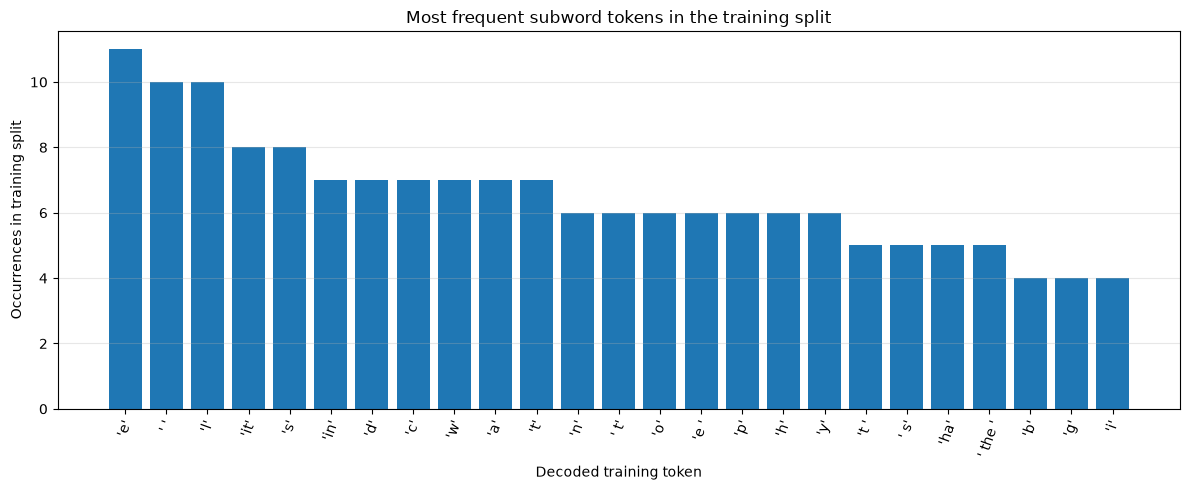

In [9]:
import matplotlib.pyplot as plt

frequency_labels = [
    repr(tokenizer.id_to_subword[token_id])
    for token_id, _ in most_common_training_tokens
]
frequency_values = [
    token_count
    for _, token_count in most_common_training_tokens
]

figure, axis = plt.subplots(figsize=(12, 5))
axis.bar(frequency_labels, frequency_values)
axis.set_xlabel("Decoded training token")
axis.set_ylabel("Occurrences in training split")
axis.set_title("Most frequent subword tokens in the training split")
axis.tick_params(axis="x", rotation=70)
axis.grid(axis="y", alpha=0.3)
figure.tight_layout()
plt.show()

Frequent tokens provide many prediction examples, while rare tokens provide fewer.

The plot describes this small corpus and should not be treated as a general English frequency distribution.

## Preview each held-apart split

Decoding a short prefix verifies that the tensors still correspond to the intended documents.

In [10]:
training_preview_ids = training_token_ids[:40].tolist()
validation_preview_ids = validation_token_ids[:40].tolist()

print("Training preview subwords:")
print(tokenizer.decode_to_subwords(training_preview_ids))
print("Training preview text:")
print(repr(tokenizer.decode(training_preview_ids)))
print()
print("Validation preview subwords:")
print(tokenizer.decode_to_subwords(validation_preview_ids))
print("Validation preview text:")
print(repr(tokenizer.decode(validation_preview_ids)))

Training preview subwords:
['Alice ', 'was ', 'b', 'e', 'g', 'in', 'n', 'ing to ', 'g', 'e', 't ', 'very', ' t', 'i', 're', 'd ', 'of', ' s', 'it', 'ting ', 'by her', ' s', 'ister', ' ', 'on', ' the b', 'an', 'k', ',', '\nan', 'd ', 'of ', 'ha', 'v', 'ing ', 'noth', 'ing to ', 'd', 'o', '.']
Training preview text:
'Alice was beginning to get very tired of sitting by her sister on the bank,\nand of having nothing to do.'

Validation preview subwords:
['T', 'he ', 'rabbit ', 'h', 'o', 'l', 'e ', 'w', 'e', 'n', 't ', 's', 't', 'r', 'a', 'i', 'g', 'h', 't ', 'on', ' ', 'l', 'i', 'k', 'e ', 'a', ' t', 'u', 'n', 'n', 'e', 'l', ' f', 'or', ' s', 'o', 'm', 'e ', 'wa', 'y']
Validation preview text:
'The rabbit hole went straight on like a tunnel for some way'


The validation preview begins at its own document boundary rather than at an arbitrary index inside the training stream.

## Build shifted GPT batches

The batching function operates only on a one-dimensional ID tensor and therefore does not care whether IDs represent characters or subwords.

The maximum valid start leaves one extra token for the final target.

In [11]:
def get_gpt_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    if token_ids.ndim != 1:
        raise ValueError("token_ids must be one-dimensional.")
    if batch_size < 1:
        raise ValueError("batch_size must be at least 1.")
    if context_length < 1:
        raise ValueError("context_length must be at least 1.")

    number_of_valid_start_positions = token_ids.shape[0] - context_length
    if number_of_valid_start_positions < 1:
        raise ValueError("token_ids must be longer than context_length.")

    start_indexes = torch.randint(
        low=0,
        high=number_of_valid_start_positions,
        size=(batch_size,),
        generator=generator,
        device=token_ids.device,
    )

    input_rows: list[torch.Tensor] = []
    target_rows: list[torch.Tensor] = []
    for start_index_tensor in start_indexes:
        start_index = int(start_index_tensor.item())
        input_rows.append(
            token_ids[start_index : start_index + context_length]
        )
        target_rows.append(
            token_ids[start_index + 1 : start_index + context_length + 1]
        )

    return torch.stack(input_rows), torch.stack(target_rows)


batch_generator = torch.Generator(device=device).manual_seed(80)
input_batch, target_batch = get_gpt_training_batch(
    token_ids=training_token_ids,
    batch_size=4,
    context_length=16,
    generator=batch_generator,
)

print("Input shape:", tuple(input_batch.shape))
print("Target shape:", tuple(target_batch.shape))
print("Shift check:", torch.equal(target_batch[:, :-1], input_batch[:, 1:]))

assert input_batch.shape == (4, 16)
assert target_batch.shape == (4, 16)
assert torch.equal(target_batch[:, :-1], input_batch[:, 1:])

Input shape: (4, 16)
Target shape: (4, 16)
Shift check: True


The target at every position is the next subword ID from the same training stream.

Validation batches can use the same function with `validation_token_ids`, but they must not be used for optimizer updates.

## Decode one batch row

The model will see IDs, while this diagnostic view confirms that the one-token shift is meaningful in text space.

In [12]:
first_input_row = input_batch[0].tolist()
first_target_row = target_batch[0].tolist()

print("Input IDs:", first_input_row)
print("Input subwords:", tokenizer.decode_to_subwords(first_input_row))
print("Input text:", repr(tokenizer.decode(first_input_row)))
print()
print("Target IDs:", first_target_row)
print("Target subwords:", tokenizer.decode_to_subwords(first_target_row))
print("Target text:", repr(tokenizer.decode(first_target_row)))

Input IDs: [90, 133, 67, 115, 22, 102, 141, 62, 22, 101, 5, 118, 25, 56, 104, 31]
Input subwords: ['i', 're', 'd ', 'of', ' s', 'it', 'ting ', 'by her', ' s', 'ister', ' ', 'on', ' the b', 'an', 'k', ',']
Input text: 'ired of sitting by her sister on the bank,'

Target IDs: [133, 67, 115, 22, 102, 141, 62, 22, 101, 5, 118, 25, 56, 104, 31, 2]
Target subwords: ['re', 'd ', 'of', ' s', 'it', 'ting ', 'by her', ' s', 'ister', ' ', 'on', ' the b', 'an', 'k', ',', '\nan']
Target text: 'red of sitting by her sister on the bank,\nan'


The decoded strings overlap by token boundaries, not necessarily by individual characters.

## Larger vocabulary changes model parameter shapes

Both the token embedding table and an untied output projection contain one row or column per vocabulary token.

For embedding dimension `64`, the output projection weight has shape `vocabulary_size x 64` and produces `vocabulary_size` scores at every position.

The calculation below compares only projection weights and excludes bias.

Embedding dimension: 64
Character vocabulary: 35
Subword vocabulary: 155
Character projection weights: 2240
Subword projection weights: 9920
Additional untied projection weights: 7680


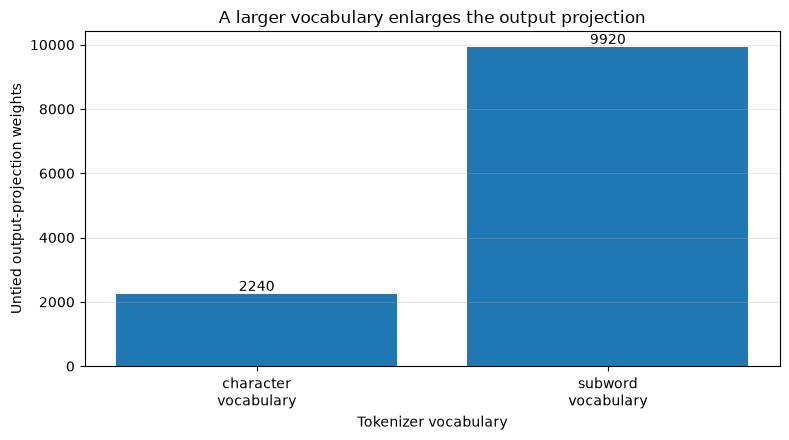

In [13]:
embedding_dimension = 64

character_output_weight_count = (
    character_vocabulary_size * embedding_dimension
)
subword_output_weight_count = (
    subword_vocabulary_size * embedding_dimension
)

print("Embedding dimension:", embedding_dimension)
print("Character vocabulary:", character_vocabulary_size)
print("Subword vocabulary:", subword_vocabulary_size)
print("Character projection weights:", character_output_weight_count)
print("Subword projection weights:", subword_output_weight_count)
print(
    "Additional untied projection weights:",
    subword_output_weight_count - character_output_weight_count,
)

projection_weight_counts = {
    "character\nvocabulary": character_output_weight_count,
    "subword\nvocabulary": subword_output_weight_count,
}

figure, axis = plt.subplots(figsize=(8, 4.5))
bars = axis.bar(
    list(projection_weight_counts),
    list(projection_weight_counts.values()),
)
axis.bar_label(bars)
axis.set_xlabel("Tokenizer vocabulary")
axis.set_ylabel("Untied output-projection weights")
axis.set_title("A larger vocabulary enlarges the output projection")
axis.grid(axis="y", alpha=0.3)
figure.tight_layout()
plt.show()

Subword tokenization shortens these text sequences but increases the number of scores computed at each model position.

If a later model ties output weights to token embeddings, the two layers share parameters, but the vocabulary dimension and number of output scores remain unchanged.

## Final dataset objects

The objects below are the direct inputs to token-level GPT training in the next chapter.

In [14]:
vocabulary_size = tokenizer.vocabulary_size

print("FINAL TOKEN-LEVEL DATASET OBJECTS")
print("=" * 60)
print("Tokenizer:", type(tokenizer).__name__)
print("Vocabulary size:", vocabulary_size)
print("Training tensor shape:", tuple(training_token_ids.shape))
print("Validation tensor shape:", tuple(validation_token_ids.shape))
print("Training tensor dtype:", training_token_ids.dtype)
print("Device:", training_token_ids.device)

FINAL TOKEN-LEVEL DATASET OBJECTS
Tokenizer: HomemadeSubwordTokenizer
Vocabulary size: 155
Training tensor shape: (374,)
Validation tensor shape: (152,)
Training tensor dtype: torch.int64
Device: cpu


## Common mistakes

- Do not train tokenizer merges on validation text when validation is meant to be held out.
- Do not create validation by slicing repeated copies of the same tiny passage and call it independent data.
- Do not use character vocabulary size when constructing the token-level model.
- Do not assume every learned token is a complete word.
- Do not compare one hundred subword tokens with one hundred characters.
- Do not count validation frequencies when describing the training distribution.
- Do not skip round-trip and ID-range checks.
- Do not let a training batch cross into the validation tensor.

## Takeaways

The tokenizer was trained only on training documents and then applied unchanged to both splits.

The notebook produced:

- the first 100 training token IDs;
- the first 100 decoded subwords;
- vocabulary and total-token counts;
- separate CPU `torch.long` training and validation tensors;
- a training-token frequency plot; and
- deterministic shifted GPT batches.

The next-token objective did not change when the representation moved from characters to subwords.

The central tradeoff is shorter sequences against a larger vocabulary, embedding table, and output-score dimension.

## What comes next

The next chapter can construct TinyGPT with `vocabulary_size = tokenizer.vocabulary_size` and train it on `training_token_ids` while estimating held-out loss on `validation_token_ids`.

The tokenizer state must remain paired with any resulting checkpoint so generated IDs retain the same meanings.